<a href="https://colab.research.google.com/github/Kavindutharaka/CycleGAN_Anime_Converter/blob/main/Cycle_Gan_Anime_Converter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets -q

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import opendatasets as od
from PIL import Image
import cv2

In [31]:
from IPython import display

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
tf.config.run_functions_eagerly(True)

In [5]:
od.download("https://www.kaggle.com/datasets/vincentv/anime-style-transfer")
od.download("https://www.kaggle.com/datasets/soumikrakshit/anime-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: elfinkavi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/vincentv/anime-style-transfer


100%|██████████| 1.44G/1.44G [00:15<00:00, 102MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: elfinkavi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/anime-faces


100%|██████████| 441M/441M [00:03<00:00, 118MB/s] 


In [6]:
human_images_directory = "/content/anime-style-transfer/anime-style-transfer/train/images"
anime_images_directory = "/content/anime-faces/data/data"
resize_human_images_directory = "/content/resize_human_images"

In [7]:
import os

In [8]:
human_images_filename = os.listdir(human_images_directory)
print(human_images_filename)

['00590.png', '00459.png', '00550.png', '00210.png', '00862.png', '00439.png', '00522.png', '00736.png', '00001.png', '00370.png', '00140.png', '00666.png', '00413.png', '00417.png', '00358.png', '00453.png', '00625.png', '00727.png', '00198.png', '00819.png', '00559.png', '00606.png', '00750.png', '00691.png', '00317.png', '00400.png', '00114.png', '00216.png', '00480.png', '00842.png', '00165.png', '00125.png', '00288.png', '00306.png', '00618.png', '00424.png', '00654.png', '00539.png', '00696.png', '00861.png', '00662.png', '00870.png', '00585.png', '00767.png', '00316.png', '00707.png', '00891.png', '00263.png', '00376.png', '00022.png', '00095.png', '00685.png', '00357.png', '00840.png', '00300.png', '00635.png', '00838.png', '00733.png', '00880.png', '00192.png', '00557.png', '00798.png', '00039.png', '00390.png', '00723.png', '00875.png', '00469.png', '00399.png', '00472.png', '00640.png', '00867.png', '00367.png', '00380.png', '00632.png', '00356.png', '00382.png', '00552.png'

In [9]:
anime_images_filename = os.listdir(anime_images_directory)
print(anime_images_filename)

['6643.png', '8757.png', '18686.png', '20483.png', '5237.png', '14611.png', '20906.png', '1515.png', '3666.png', '6315.png', '7087.png', '19379.png', '3873.png', '19177.png', '21329.png', '10102.png', '3335.png', '14525.png', '17516.png', '519.png', '17285.png', '14154.png', '16895.png', '19049.png', '1706.png', '12638.png', '2036.png', '20487.png', '3043.png', '2803.png', '21360.png', '13339.png', '21382.png', '15704.png', '11416.png', '9761.png', '5094.png', '21291.png', '17207.png', '14612.png', '16828.png', '20388.png', '11178.png', '2177.png', '2198.png', '11576.png', '7908.png', '12042.png', '11804.png', '11039.png', '19826.png', '13279.png', '3482.png', '1363.png', '21392.png', '3209.png', '17709.png', '21184.png', '6218.png', '3087.png', '17634.png', '7126.png', '15835.png', '2510.png', '6247.png', '18244.png', '1371.png', '17981.png', '19150.png', '14688.png', '20261.png', '5689.png', '8357.png', '15038.png', '3829.png', '13636.png', '11519.png', '10191.png', '980.png', '6689.

In [10]:
image_size = (64, 64)
human_images_dataset = []
for filename in human_images_filename[:820]:
  img_dir = os.path.join(human_images_directory,filename)
  img = cv2.imread(img_dir)
  if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, image_size)
    img = (img.astype(np.float32)-127.5)/127.5
    human_images_dataset.append(img)

In [11]:
human_dataset = np.array(human_images_dataset, dtype=np.float32)
human_dataset.shape

(820, 64, 64, 3)

In [12]:
print(human_dataset[0].shape)

(64, 64, 3)


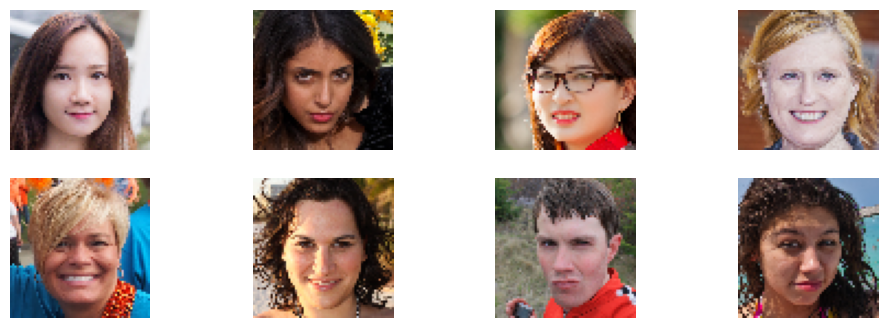

In [13]:
np.random.shuffle(human_dataset)
plt.figure(figsize=(12,4))

for i in range(8) :
  plt.subplot(2,4,i+1)
  img = ((human_dataset[i]*127.5)+127.5).clip(0,255).astype(np.uint8)
  plt.imshow(img)
  plt.axis("off")

plt.show()

In [14]:
anime_image_dataset = []
for filename in anime_images_filename[:820]:
  img_dir = os.path.join(anime_images_directory, filename)
  img = cv2.imread(img_dir)
  if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, image_size)
    img = (img.astype(np.float32)-127.5)/127.5
    anime_image_dataset.append(img)

In [15]:
anime_dataset = np.array(anime_image_dataset, dtype=np.float32)
anime_dataset.shape

(820, 64, 64, 3)

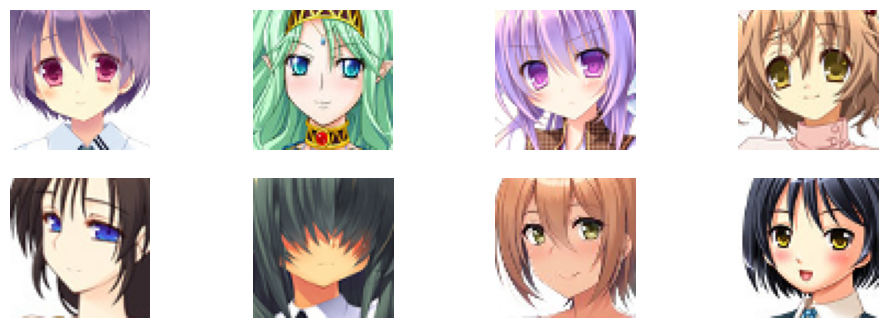

In [16]:
plt.figure(figsize=(12, 4))

for i in range(8):
  plt.subplot(2, 4, i + 1)
  img = ((anime_dataset[i]*127.5)+127.5).clip(0,255).astype(np.uint8)
  plt.imshow(img)
  plt.axis("off")

plt.show()

In [17]:
from tensorflow.keras.layers import Conv2D,LeakyReLU,ReLU,Input,Conv2DTranspose,Add
from tensorflow.keras.models import Model

In [18]:
def build_generator():
  inputs = Input(shape=(64, 64, 3))
  #Decode
  x = Conv2D(64, (4,4), strides=2, padding="same")(inputs)
  x = LeakyReLU(alpha=0.2)(x)
  x = Conv2D(128, (4,4), strides=2, padding="same")(x)
  x = LeakyReLU(alpha=0.2)(x)
  #Residual Blocks
  for _ in range(5):
    res = Conv2D(128, (3,3), padding="same")(x)
    res = ReLU()(res)
    res = Conv2D(128, (3,3), padding="same")(res)
    res = Add()([x, res])
    x = ReLU()(res)
  #Upsampling
  x = Conv2DTranspose(64,(4,4), strides=2, padding="same")(x)
  x = ReLU()(x)
  x = Conv2DTranspose(3,(4,4), strides=2, padding="same", activation="tanh")(x)

  return Model(inputs,x)

In [19]:
def build_discriminator():
  inputs = Input(shape=(64, 64, 3))

  x = Conv2D(64, (4,4), strides=2, padding="same")(inputs)
  x = LeakyReLU(alpha=0.2)(x)
  x = Conv2D(128, (4,4), strides=2, padding="same")(x)
  x = LeakyReLU(alpha=0.2)(x)

  x = Conv2D(1,(4,4), padding="same")(x)

  return Model(inputs, x)


In [20]:
def cycle_consistency_loss(real_image, cycled_image):
  return tf.reduce_mean(tf.abs(real_image-cycled_image))

In [22]:
import time
class CycleGAN(tf.keras.Model):
  def __init__(self):
    super(CycleGAN, self).__init__()
    self.gen_G = build_generator() #human --> anime
    self.gen_F = build_generator() #anime --> human
    self.disc_A = build_discriminator() #human
    self.disc_B = build_discriminator() #anime
    self._current_epoch = 0
    self._epoch_start_time = 0

  def compile(self, gen_optimizer_G, gen_optimizer_F, disc_optimizer_A, disc_optimizer_B, cycle_loss_fn, gen_loss_fn, disc_loss_fn):
    super(CycleGAN, self).compile()
    self.gen_optimizer_G = gen_optimizer_G
    self.gen_optimizer_F = gen_optimizer_F
    self.disc_optimizer_A = disc_optimizer_A
    self.disc_optimizer_B = disc_optimizer_B
    self.cycle_loss_fn = cycle_loss_fn
    self.gen_loss_fn = gen_loss_fn
    self.disc_loss_fn = disc_loss_fn

  def on_epoch_begin(self, epoch, logs=None):
    self._current_epoch = epoch
    self._epoch_start_time = time.time()

  def call(self, inputs, training=None):
    real_human, real_anime = inputs[0], inputs[1]

    fake_anime = self.gen_G(real_human, training=training)
    fake_human = self.gen_F(real_anime, training=training)

    cycled_B = self.gen_G(fake_human, training=training)
    cycled_A = self.gen_F(fake_anime, training=training)

    disc_real_A = self.disc_A(real_human, training=training)
    disc_fake_A = self.disc_A(fake_human, training=training)
    disc_real_B = self.disc_B(real_anime, training=training)
    disc_fake_B = self.disc_B(fake_anime, training=training)

    return fake_human, fake_anime, cycled_A, cycled_B, disc_real_A, disc_fake_A, disc_real_B, disc_fake_B

  def train_step(self, data):
    # real_human = human_dataset
    # real_anime = anime_dataset
    real_human, real_anime = data[0], data[1]

    with tf.GradientTape(persistent=True) as tape:
      #fake_anime = self.gen_G(real_human)
      #fake_human = self.gen_F(real_anime)

      #cycled_human = self.gen_F(fake_anime)
      #cycled_anime = self.gen_G(fake_human)

      #disc_real_human = self.disc_A(real_human)
      #disc_real_anime = self.disc_B(real_anime)
      #disc_fake_human = self.disc_A(fake_human)
      #disc_fake_anime = self.disc_B(fake_anime)

      fake_human, fake_anime, cycled_human, cycled_anime, disc_real_human, disc_fake_human, disc_real_anime, disc_fake_anime = self(
          (real_human, real_anime), training=True
      )

      cycle_loss = self.cycle_loss_fn(real_human, cycled_human) + self.cycle_loss_fn(real_anime, cycled_anime)
      gen_G_loss = self.gen_loss_fn(disc_fake_anime) + cycle_loss
      gen_F_loss = self.gen_loss_fn(disc_fake_human) + cycle_loss
      disc_A_loss = self.disc_loss_fn(disc_real_human, disc_fake_human)
      disc_B_loss = self.disc_loss_fn(disc_real_anime, disc_fake_anime)

    gen_G_grads = tape.gradient(gen_G_loss, self.gen_G.trainable_variables)
    gen_F_grads = tape.gradient(gen_F_loss, self.gen_F.trainable_variables)
    disc_A_grads = tape.gradient(disc_A_loss, self.disc_A.trainable_variables)
    disc_B_grads = tape.gradient(disc_B_loss, self.disc_B.trainable_variables)

    self.gen_optimizer_G.apply_gradients(zip(gen_G_grads, self.gen_G.trainable_variables))
    self.gen_optimizer_F.apply_gradients(zip(gen_F_grads, self.gen_F.trainable_variables))
    self.disc_optimizer_A.apply_gradients(zip(disc_A_grads, self.disc_A.trainable_variables))
    self.disc_optimizer_B.apply_gradients(zip(disc_B_grads, self.disc_B.trainable_variables))

    elapsed_time = time.time() - self._epoch_start_time
    minutes = int(elapsed_time // 60)
    seconds = int(elapsed_time % 60)
    tf.print(f"Time for step: {minutes} minutes {seconds} seconds")

    return {"gen_G_loss": gen_G_loss, "gen_F_loss": gen_F_loss, "disc_A_loss": disc_A_loss, "disc_B_loss": disc_B_loss }


In [23]:
class SaveGeneratedImagesCallback(tf.keras.callbacks.Callback):
    def __init__(self, gen_G, gen_F, human_samples, anime_samples, save_dir, num_images=8):
        super().__init__()
        self.gen_G = gen_G
        self.gen_F = gen_F
        self.human_samples = human_samples
        self.anime_samples = anime_samples
        self.save_dir = save_dir
        self.num_images = num_images
        os.makedirs(save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        # Generate images
        fake_anime = self.gen_G(self.human_samples, training=False)
        fake_human = self.gen_F(self.anime_samples, training=False)

        # Plot
        plt.figure(figsize=(20, 15))
        for i in range(self.num_images):
            # Real Human to Fake Anime
            plt.subplot(4, self.num_images, i+1)
            plt.imshow((self.human_samples[i] * 127.5 + 127.5).astype(np.uint8))
            plt.axis('off')
            if i == 0:
                plt.title('Real Human')

            plt.subplot(4, self.num_images, i+1 + self.num_images)
            plt.imshow((fake_anime[i] * 127.5 + 127.5).numpy().astype(np.uint8))
            plt.axis('off')
            if i == 0:
                plt.title('Fake Anime')

            # Real Anime to Fake Human
            plt.subplot(4, self.num_images, i+1 + 2*self.num_images)
            plt.imshow((self.anime_samples[i] * 127.5 + 127.5).astype(np.uint8))
            plt.axis('off')
            if i == 0:
                plt.title('Real Anime')

            plt.subplot(4, self.num_images, i+1 + 3*self.num_images)
            plt.imshow((fake_human[i] * 127.5 + 127.5).numpy().astype(np.uint8))
            plt.axis('off')
            if i == 0:
                plt.title('Fake Human')

        plt.suptitle(f'Epoch {epoch+1}', y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, f'epoch_{epoch+1}.png'))
        plt.close()
        display.clear_output(wait=True)

In [24]:
batch_size = 16
dataset_human = tf.data.Dataset.from_tensor_slices(human_dataset).batch(batch_size)
dataset_anime = tf.data.Dataset.from_tensor_slices(anime_dataset).batch(batch_size)
zipped_dataset = tf.data.Dataset.zip((dataset_human, dataset_anime))

In [25]:
cyclegan = CycleGAN()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [27]:
cyclegan.compile(
    gen_optimizer_G = tf.keras.optimizers.Adam(2e-4, beta_1=0.5),
    gen_optimizer_F = tf.keras.optimizers.Adam(2e-4, beta_1=0.5),
    disc_optimizer_A = tf.keras.optimizers.Adam(2e-4, beta_1=0.5),
    disc_optimizer_B = tf.keras.optimizers.Adam(2e-4, beta_1=0.5),
    cycle_loss_fn  = cycle_consistency_loss,
    gen_loss_fn = lambda fake: tf.reduce_mean(tf.square(fake - 1)),
    disc_loss_fn = lambda real, fake:tf.reduce_mean(tf.square(real - 1)) + tf.reduce_mean(tf.square(fake))
)

In [28]:
checkpoint_dir = '/content/drive/MyDrive/GAN/Human trasfer Anime CycleGAN'
checkpoint = tf.train.Checkpoint(gen_G=cyclegan.gen_G,
                                 gen_F=cyclegan.gen_F,
                                 disc_A=cyclegan.disc_A,
                                 disc_B=cyclegan.disc_B,
                                 gen_optimizer_G=cyclegan.gen_optimizer_G,
                                 gen_optimizer_F=cyclegan.gen_optimizer_F,
                                 disc_optimizer_A=cyclegan.disc_optimizer_A,
                                 disc_optimizer_B=cyclegan.disc_optimizer_B)
checkpoint_manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=3)
checkpoint_callback = tf.keras.callbacks.LambdaCallback(on_epoch_end=lambda epoch, logs: checkpoint_manager.save())

In [29]:
save_image_dir = '/content/drive/MyDrive/GAN/Human trasfer Anime CycleGAN'
sample_human = human_dataset[:8]
sample_anime = anime_dataset[:8]
image_callback = SaveGeneratedImagesCallback(cyclegan.gen_G, cyclegan.gen_F, sample_human, sample_anime, save_image_dir)

In [32]:
cyclegan.fit(
    zipped_dataset,
    epochs=100,
    callbacks=[checkpoint_callback, image_callback]
)

52/52 ━━━━━━━━━━━━━━━━━━━━ 42s 749ms/step - disc_A_loss: 0.4999 - disc_B_loss: 0.4925 - gen_F_loss: 0.5546 - gen_G_loss: 0.5628
